<a href="https://colab.research.google.com/github/mjcolebank/Colebank_REU_2026/blob/main/BCNN%201K/Model5_BayesianCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bayesian Modeling with Pyro and PyTorch



GOOD ATTEMPT FOR 1K

Anna's version of Dr. Colebank's BCNN_ECG code:

This code uses batch norm, kernel size 5, and 150 filters.
Train accuracy: 0.78125
Test accuracy: 0.77

In [ ]:
'''
This code uses batch norm, kernel size 5, and 150 filters.
Train accuracy: 0.78125
Test accuracy: 0.77
'''

ECG_metrics_10K.npy  ECG_waveforms_1K.zip      fft_time_series_analysis.ipynb
ECG_metrics_1K.npy   EchoNext_EchoData_5K.csv  Visualizing_ECGs_REU.ipynb


In [ ]:
# Uncomment this line if Pyro is not installed.
%pip install pyro-ppl torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 10.5 MB/s eta 0:00:00


In [ ]:
from re import X
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks

ECG_data_1K = np.load('ECG_waveforms_1K.npy')
# ECG_summary_1K = np.load('ECG_metrics_1K.npy')
Echo_5K = pd.read_csv('EchoNext_EchoData_5K.csv')

labels = Echo_5K['shd_moderate_or_greater_flag']


#initial definitions
negative = labels==0
positive = labels==1
y_ts = np.array(labels[:1000])
X = ECG_data_1K[:1000]
X_ts = np.swapaxes(X, 1, 2)
print(X_ts.shape)
print(y_ts.shape)


## 1. Imports and Reproducibility

We will use:

- `torch` for tensors, neural network layers, and optimization.
- `pyro` for probabilistic models and variational inference.
- `torchvision` for MNIST.
- `matplotlib` for visualization.

In [ ]:
import math
import os
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Subset

import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.nn import PyroModule, PyroSample
from pyro.optim import Adam

try:
    from torchvision import datasets, transforms
    TORCHVISION_AVAILABLE = True
except Exception as e:
    TORCHVISION_AVAILABLE = False
    print("torchvision could not be imported:", e)

In [ ]:
def set_seed(seed=0):
    """Set random seeds for reproducible examples."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)
pyro.set_rng_seed(42)
pyro.clear_param_store()

# Use a GPU if one is available. Otherwise use the CPU.
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
print("Using device:", device)

Using device: cpu


# Part I: Bayesian Linear Regression

## 2. Mathematical Model

Suppose we observe pairs $(x_i, y_i)$. A standard linear regression model assumes

$$
y_i = wx_i + b + \epsilon_i,
$$

where $w$ is the slope, $b$ is the intercept, and $\epsilon_i$ is random noise.

In a **Bayesian** model, we place prior distributions on unknown quantities. For example:

$$
w \sim \mathcal{N}(0, 10),
$$

$$
b \sim \mathcal{N}(0, 10),
$$

$$
\sigma \sim \text{LogNormal}(0, 1),
$$

$$
y_i \mid x_i, w, b, \sigma \sim \mathcal{N}(wx_i + b, \sigma).
$$

After observing data, the posterior distribution tells us which values of \(w\), \(b\), and \($\sigma$\) are plausible.

# Part II: Bayesian CNN for MNIST

## 9. CNN Classification Setup

MNIST contains grayscale images of handwritten digits. Each image has shape \(1 \times 28 \times 28\), and the label is one of 10 classes.

A conventional CNN learns fixed convolutional filters. A Bayesian CNN places probability distributions over the filters and dense-layer weights.

In this example, we use a very small CNN:

1. Bayesian convolution layer from 1 channel to 4 channels.
2. ReLU and max pooling.
3. Bayesian convolution layer from 4 channels to 8 channels.
4. ReLU and max pooling.
5. Bayesian fully connected hidden layer.
6. Bayesian output layer for 10 digit classes.

Because the CNN weights are random variables, prediction is performed by sampling multiple networks from the posterior and averaging their predicted probabilities.

## 10. Load MNIST

The next cell downloads MNIST using `torchvision`. To keep the Bayesian CNN example fast, we use small subsets by default.

You can increase `train_subset_size`, `test_subset_size`, `num_epochs`, or `max_batches_per_epoch` if you want a more serious experiment.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import sympy
import sympy.core          # force submodule onto the namespace
import sympy.core.symbol
import torch               # now import torch

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

import importlib
sympy.core = importlib.import_module("sympy.core")
sympy.core.symbol = importlib.import_module("sympy.core.symbol")
print(hasattr(sympy, 'core'))

# Optional imports for MNIST.
# If torchvision is not installed, the synthetic time-series example will still run.

try:
    import torchvision
    import torchvision.transforms as transforms
    TORCHVISION_AVAILABLE = True
except ImportError:
    TORCHVISION_AVAILABLE = False

np.random.seed(42)
torch.manual_seed(42) #42

# Use a GPU if available. Otherwise, use CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


True
Using device: cpu


In [ ]:
from re import X
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks

ECG_data_1K = np.load('ECG_waveforms_1K.npy')
ECG_summary_1K = np.load('ECG_metrics_1K.npy')
Echo_5K = pd.read_csv('EchoNext_EchoData_5K.csv')

labels = Echo_5K['shd_moderate_or_greater_flag']


#initial definitions
negative = labels==0
positive = labels==1
y_ts = np.array(labels[:1000])
X = ECG_data_1K[:1000]
X_ts = np.swapaxes(X, 1, 2)
print(X_ts.shape)
print(y_ts.shape)


(1000, 12, 2500)
(1000,)


In [ ]:
labels = Echo_5K['shd_moderate_or_greater_flag']

y_ts = np.array(labels[:1000])
X = ECG_data_1K[:1000]
X_ts = np.swapaxes(X, 1, 2)

print(np.bincount(y_ts))
print("Majority-class baseline:", max(np.bincount(y_ts)) / len(y_ts))

[477 523]
Majority-class baseline: 0.523


In [ ]:
#train & test
X_ts_tensor = torch.tensor(X_ts, dtype=torch.float32)
y_ts_tensor = torch.tensor(y_ts, dtype=torch.long)

ts_dataset = TensorDataset(X_ts_tensor, y_ts_tensor)

train_size = int(0.8 * len(ts_dataset))
test_size = len(ts_dataset) - train_size

ts_train_dataset, ts_test_dataset = random_split(
    ts_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

ts_train_loader = DataLoader(ts_train_dataset, batch_size=32, shuffle=True) #change batch size
batch = next(iter(ts_train_loader))
print(batch[0].shape)

ts_test_loader = DataLoader(ts_test_dataset, batch_size=128, shuffle=False)

print("Time-series training samples:", len(ts_train_dataset))
print("Time-series test samples:", len(ts_test_dataset))


torch.Size([32, 12, 2500])
Time-series training samples: 800
Time-series test samples: 200


## 12. Define a Bayesian CNN with PyroModule and PyroSample

`PyroModule` allows a PyTorch module to contain random parameters.

`PyroSample` replaces a deterministic parameter, such as a weight tensor, with a prior distribution. During inference, Pyro learns an approximate posterior over these random tensors.

The model below uses:

- Normal priors for convolution and dense weights.
- Categorical likelihood for class labels.
- Logits returned by the CNN.

The final likelihood is

$$
y_i \mid x_i, \theta \sim \text{Categorical}(\text{logits}=f_\theta(x_i)),
$$

where $\theta$ represents all Bayesian weights and biases.

In [ ]:
class BayesianSmallCNN(PyroModule):
    def __init__(self, prior_scale=0.10,pooled_len = 1): #ask
        super().__init__()
        self.pooled_len = pooled_len
        self.conv1 = PyroModule[nn.Conv1d](12, 150, kernel_size=5, padding=2)
        self.conv1.weight = PyroSample(
            dist.Normal(0.0, prior_scale).expand([150, 12, 5]).to_event(3) #ask about expand, to_event
        )
        self.conv1.bias = PyroSample(
            dist.Normal(0.0, prior_scale).expand([150]).to_event(1)
        )

        self.conv2 = PyroModule[nn.Conv1d](150, 150, kernel_size=5, padding=2)
        self.conv2.weight = PyroSample(
            dist.Normal(0.0, prior_scale).expand([150, 150, 5]).to_event(3)
        )
        self.conv2.bias = PyroSample(
            dist.Normal(0.0, prior_scale).expand([150]).to_event(1)
        )

        self.bn1 = nn.BatchNorm1d(150)
        self.bn2 = nn.BatchNorm1d(150)

        flattened_dim = 150

        #flattened_dim = 12 * self.pooled_len

        self.fc1 = PyroModule[nn.Linear](flattened_dim, 32)
        self.fc1.weight = PyroSample(
            dist.Normal(0.0, prior_scale).expand([32, flattened_dim]).to_event(2)
        )
        self.fc1.bias = PyroSample(
            dist.Normal(0.0, prior_scale).expand([32]).to_event(1)
        )

        self.fc2 = PyroModule[nn.Linear](32, 2)
        self.fc2.weight = PyroSample(
            dist.Normal(0.0, prior_scale).expand([2, 32]).to_event(2)
        )
        self.fc2.bias = PyroSample(
            dist.Normal(0.0, prior_scale).expand([2]).to_event(1)
        )

    def forward(self, x, y=None, dataset_size=None):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        #x = F.tanh(self.conv1(x))
        x = F.max_pool1d(x, kernel_size=2)

        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        #x = F.tanh(self.conv2(x))
        x = F.max_pool1d(x, kernel_size=2)

        #x = torch.flatten(x, start_dim=1)
        x = F.adaptive_avg_pool1d(x, 1)
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        #x = F.relu(tanh.fc1(x))
        logits = self.fc2(x)

        if y is not None and dataset_size is not None:
            scale = dataset_size / x.shape[0]
        else:
            scale = 1.0

        with pyro.plate("data", x.shape[0]):
            with pyro.poutine.scale(scale=scale):
                pyro.sample("obs", dist.Categorical(logits=logits), obs=y)

        return logits

## 13. Create the Guide and SVI Object

We again use `AutoDiagonalNormal`. For a Bayesian CNN, this means Pyro creates a diagonal Normal variational posterior over all Bayesian weights and biases.

This is not the only possible guide, but it is a clear starting point for teaching and experimentation.

In [ ]:
pyro.clear_param_store()
set_seed(72)

bcnn = BayesianSmallCNN(prior_scale=2.0).to(device)
bcnn_guide = AutoDiagonalNormal(bcnn)

bcnn_optimizer = Adam({"lr": 1e-3,"betas": (0.9, 0.999)})
bcnn_svi = SVI(
    model=bcnn,
    guide=bcnn_guide,
    optim=bcnn_optimizer,
    loss=Trace_ELBO(),
)

## 14. Training and Evaluation Utilities

The training loop is similar to ordinary PyTorch, except the optimization step is `svi.step(images, labels)` rather than `loss.backward()` followed by `optimizer.step()`.

For prediction, we sample several networks from the approximate posterior and average their softmax probabilities.

In [ ]:
def train_one_epoch_svi(svi, data_loader, device, dataset_size, max_batches=None):
    total_loss = 0.0
    total_examples = 0

    for batch_idx, (x, y) in enumerate(data_loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x = x.to(device)
        y = y.to(device)

        loss = svi.step(x, y, dataset_size)
        total_loss += loss
        total_examples += x.shape[0]

    return total_loss / max(1, total_examples)

@torch.no_grad()
def predict_proba_bayesian(model, guide, x, num_samples=2500):
    """Average class probabilities over posterior samples of the network."""
    predictive = Predictive(
        model,
        guide=guide,
        num_samples=num_samples,
        return_sites=("_RETURN",),
    )
    out = predictive(x, None)

    # Shape is usually [num_samples, batch_size, num_classes].
    logits_samples = out["_RETURN"]
    probs_samples = torch.softmax(logits_samples, dim=-1)
    mean_probs = probs_samples.mean(dim=0)
    return mean_probs


@torch.no_grad()
def evaluate_bayesian_classifier(model, guide, data_loader, device, num_samples=2500, max_batches=None):
    """Evaluate posterior-averaged classification accuracy."""
    correct = 0
    total = 0

    for batch_idx, (x, y) in enumerate(data_loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x = x.to(device)
        y = y.to(device)
        mean_probs = predict_proba_bayesian(model, guide, x, num_samples=num_samples)
        preds = mean_probs.argmax(dim=-1)
        correct += (preds == y).sum().item()
        total += y.numel()

    return correct / max(1, total)

## 15. Train the Bayesian CNN

This cell uses conservative defaults so it can run on a laptop. For better performance, try increasing:

- `train_subset_size`
- `num_epochs`
- `max_batches_per_epoch`
- `num_prediction_samples`

Fully Bayesian CNNs are much slower than deterministic CNNs because each prediction can require many posterior samples.

Epoch  1/20 | avg negative ELBO per example = 10079.17 | approx test accuracy = 0.775
Epoch  2/20 | avg negative ELBO per example = 9974.29 | approx test accuracy = 0.750
Epoch  3/20 | avg negative ELBO per example = 9878.87 | approx test accuracy = 0.770
Epoch  4/20 | avg negative ELBO per example = 9782.08 | approx test accuracy = 0.765
Epoch  5/20 | avg negative ELBO per example = 9691.26 | approx test accuracy = 0.770
Epoch  6/20 | avg negative ELBO per example = 9596.38 | approx test accuracy = 0.755
Epoch  7/20 | avg negative ELBO per example = 9507.06 | approx test accuracy = 0.715
Epoch  8/20 | avg negative ELBO per example = 9413.57 | approx test accuracy = 0.790
Epoch  9/20 | avg negative ELBO per example = 9317.88 | approx test accuracy = 0.740
Epoch 10/20 | avg negative ELBO per example = 9225.03 | approx test accuracy = 0.790
Epoch 11/20 | avg negative ELBO per example = 9134.84 | approx test accuracy = 0.755
Epoch 12/20 | avg negative ELBO per example = 9042.88 | approx t

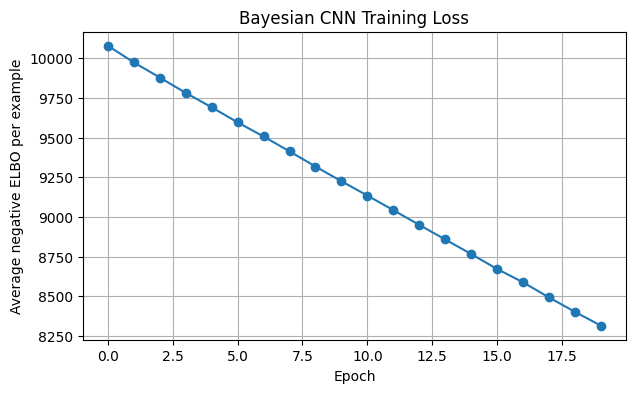

In [ ]:
num_epochs = 20
max_batches_per_epoch = None
num_prediction_samples = 15

bcnn_losses = []

for epoch in range(num_epochs):
    avg_loss = train_one_epoch_svi(
    bcnn_svi,
    ts_train_loader,
    device,
    dataset_size = train_size,
    max_batches=max_batches_per_epoch,
)
    bcnn_losses.append(avg_loss)

    test_acc = evaluate_bayesian_classifier(
        bcnn,
        bcnn_guide,
        ts_test_loader,
        device,
        num_samples=num_prediction_samples,
        max_batches=5,
    )

    print(
        f"Epoch {epoch + 1:2d}/{num_epochs} | "
        f"avg negative ELBO per example = {avg_loss:.2f} | "
        f"approx test accuracy = {test_acc:.3f}"
    )

plt.figure(figsize=(7, 4))
plt.plot(bcnn_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Average negative ELBO per example")
plt.title("Bayesian CNN Training Loss")
plt.grid(True)
plt.show()

In [ ]:
train_acc = evaluate_bayesian_classifier(
    bcnn,
    bcnn_guide,
    ts_train_loader,
    device,
    num_samples=100
)

test_acc = evaluate_bayesian_classifier(
    bcnn,
    bcnn_guide,
    ts_test_loader,
    device,
    num_samples=100
)

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)

Train accuracy: 0.78125
Test accuracy: 0.77


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import torch

@torch.no_grad()
def get_predictions(model, guide, data_loader, device, num_samples=250):
    all_preds = []
    all_labels = []

    for x, y in data_loader:
        x = x.to(device)
        y = y.to(device)

        mean_probs = predict_proba_bayesian(
            model, guide, x, num_samples=num_samples
        )
        preds = mean_probs.argmax(dim=-1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)


y_true, y_pred = get_predictions(
    bcnn,
    bcnn_guide,
    ts_test_loader,
    device,
    num_samples=250
)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

## 16. Visualize Bayesian CNN Predictions

The predicted class is obtained by averaging softmax probabilities over posterior samples.

The maximum averaged probability gives a simple uncertainty summary:

- High value: the posterior ensemble mostly agrees.
- Low value: the posterior ensemble is less confident.

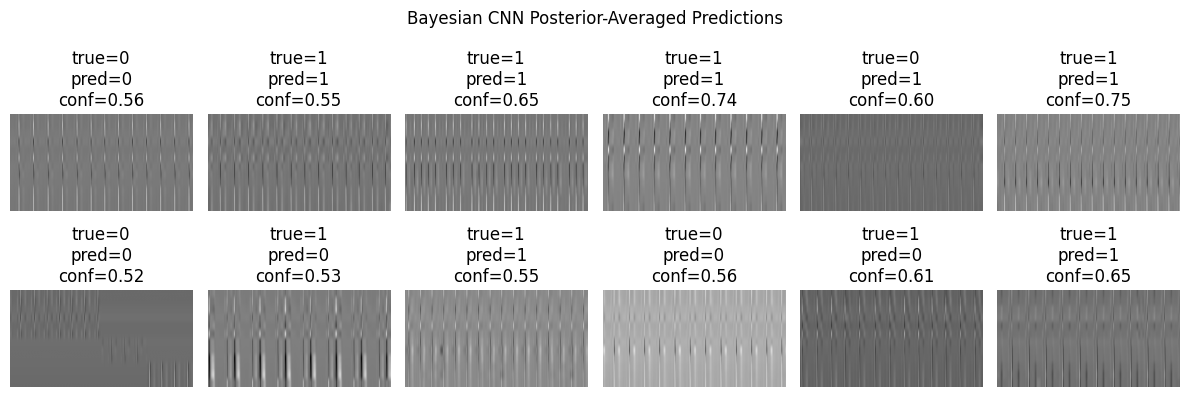

In [ ]:
images, labels = next(iter(ts_test_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    mean_probs = predict_proba_bayesian(
        bcnn,
        bcnn_guide,
        images[:12],
        num_samples=30,
    )
    pred_labels = mean_probs.argmax(dim=-1)
    confidences = mean_probs.max(dim=-1).values

plt.figure(figsize=(12, 4))
for i in range(12):
    plt.subplot(2, 6, i + 1)
    plt.imshow(images[i].detach().cpu().numpy(), aspect="auto", cmap="gray")
    plt.title(
        f"true={labels[i].item()}\n"
        f"pred={pred_labels[i].item()}\n"
        f"conf={confidences[i].item():.2f}"
    )
    plt.axis("off")
plt.suptitle("Bayesian CNN Posterior-Averaged Predictions")
plt.tight_layout()
plt.show()

## 17. Class Probability Bar Plot for One Image

A Bayesian classifier gives a distribution over model weights. After averaging over posterior samples, we get posterior-averaged class probabilities.

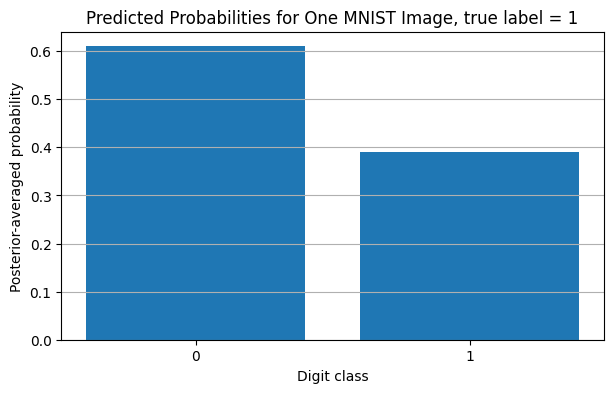

In [ ]:
example_index = 10
probs = mean_probs[example_index].detach().cpu().numpy()

plt.figure(figsize=(7, 4))
plt.bar(np.arange(2), probs)
plt.xticks(np.arange(2))
plt.xlabel("Digit class")
plt.ylabel("Posterior-averaged probability")
plt.title(f"Predicted Probabilities for One MNIST Image, true label = {labels[example_index].item()}")
plt.grid(True, axis="y")
plt.show()

## 18. Optional: Compare With a Deterministic CNN

This optional section gives a standard PyTorch CNN with the same architecture. It is useful for comparison because deterministic CNN training is usually much faster than Bayesian CNN training.

Unlike the Bayesian CNN, this model learns a single point estimate for each parameter.

In [ ]:
class DeterministicSmallCNN(nn.Module):
    """A deterministic CNN with the same architecture as the Bayesian CNN."""

    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(4, 8, kernel_size=5, padding=2)
        self.fc1 = nn.Linear(8 * 7 * 7, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        logits = self.fc2(x)
        return logits

In [ ]:
# Optional deterministic training example.
# Uncomment to run.

det_model = DeterministicSmallCNN().to(device)
det_optimizer = torch.optim.Adam(det_model.parameters(), lr=1e-3,betas=(0.9,0.999))
criterion = nn.CrossEntropyLoss()

for epoch in range(20):
    det_model.train()
    total_loss = 0.0
    total_examples = 0
    for batch_idx, (x, y) in enumerate(train_loader):
        x = x.to(device)
        y = y.to(device)

        det_optimizer.zero_grad()
        logits = det_model(x)
        loss = criterion(logits, y)
        loss.backward()
        det_optimizer.step()

        total_loss += loss.item() * x.shape[0]
        total_examples += x.shape[0]

    print(f"Epoch {epoch + 1}: deterministic avg CE loss = {total_loss / total_examples:.3f}")

NameError: name 'train_loader' is not defined

In [ ]:
images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    det_pred =         logits = det_model(images[:12])
    # print(det_pred)
    pred_labels = det_pred.argmax(dim=-1)

plt.figure(figsize=(9, 8))
for i in range(12):
    plt.subplot(2, 6, i + 1)
    plt.imshow(images[i, 0].detach().cpu().numpy(), cmap="gray")
    plt.title(
        f"true={labels[i].item()}\n"
        f"pred={pred_labels[i].item()}\n"
    )
    plt.axis("off")
plt.suptitle("Frequentist CNN Posterior-Averaged Predictions")
plt.tight_layout()
plt.show()

# 19. Summary

In this notebook, we implemented two Pyro-based Bayesian models:

1. **Bayesian linear regression**
   - Priors on slope, intercept, and noise.
   - SVI with an automatic diagonal Normal guide.
   - Posterior predictive uncertainty intervals.

2. **Bayesian CNN for MNIST**
   - Priors on convolutional and dense weights.
   - Categorical likelihood for digit classification.
   - Posterior-averaged predictions.
   - Simple confidence estimates from averaged class probabilities.

Key ideas:

- Bayesian models represent uncertainty in parameters.
- Pyro models use `pyro.sample` to define random variables.
- Guides approximate the posterior distribution.
- SVI trains the guide by optimizing the ELBO.
- Prediction averages over posterior samples rather than relying on a single set of weights.

For a larger MNIST experiment, increase the subset size and number of epochs. For faster experimentation, make only the final layer Bayesian while keeping earlier convolutional layers deterministic.